In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from graph_vis import draw_dot
import math

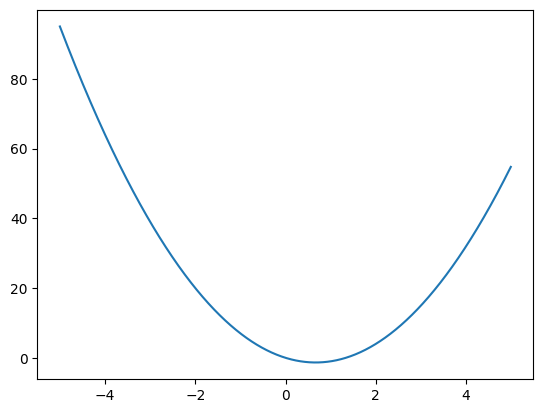

In [4]:
def f(x):
    return 3 * x**2 - 4 * x

xs = np.arange(-5, 5, 0.01)
ys = f(xs)
plt.plot(xs, ys)
plt.show()

In [5]:
# Derivative
x = -10
h = 0.00000001
(f(x + h) - f(x))/h

-64.00000529538374

In [6]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d = a*b + c

b += h
d2 = a*b + c

print("d1: ", d)
print("d2: ", d2)
print("slope: ", (d2 - d)/h)

d1:  4.0
d2:  4.0002
slope:  2.0000000000042206


In [7]:
class Value:
    def __init__(self, data, _children=(), _op='', label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad=0
        self._backward = lambda:None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        tanx = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(tanx, (self, ), _op='tanh')

        def _backward():
            self.grad += (1 - tanx**2) * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other    
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)

    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int / float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            x = self.data
            self.grad += other * (x**(other -1)) *out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), _op='exp')

        def _backward():
            self.grad += math.exp(x) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [8]:
# Implement a simple NN manually

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1.__mul__(w1); x1w1.label='x1w1'
x2w2 = x2.__mul__(w2); x2w2.label='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'

n = x1w1x2w2 + b; n.label='n'

e = (2 * n).exp(); e.label = 'e'

o =  (e - 1) / (e + 1); o.label = 'o'

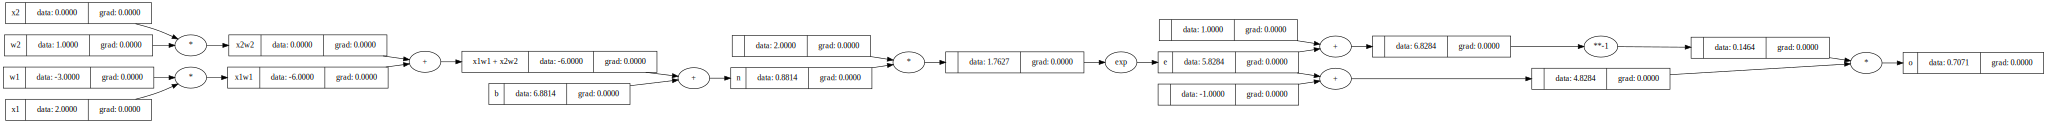

In [9]:
draw_dot(o)

In [10]:
# ====================
# | MANUAL BACKPROP  |
# ====================
# o.grad = 1.0
# n.grad = 1 - o.data**2 # diff(tanh(x)) = 1 - tanh(x) ** 2
# b.grad = 1.0 * n.grad # dn/db = 1; n = x1w1 + x2w2 + b

# x1w1x2w2.grad = 1.0 * n.grad # dn / d(x1w1+x2w1) = 1.0; see 'n'
# x1w1.grad = 1.0 * x1w1x2w2.grad # d(x1w1 + x2w2) / d(x1w1) = 1.0
# x2w2.grad = 1.0 * x1w1x2w2.grad
# # do/dx1 = do/dn * dn/d(x1w1+x2w2) * d(x1w1+x2w2)/d(x1w1) * d(x1w1)/dx1 ==> chain rule || d(x1w1)/dx1 ==> local
# x1.grad = w1.data * x1w1.grad # d(x1w1)/d(x1) = w1 ==> local; x1w1.grad ==> global
# w1.grad = x1.data * x1w1.grad

# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad


In [11]:
#  CALLING BACKPROP FOR EVERY NODE|
# =================================

# o.grad = 1.0
# o._backward()
# n._backward()

# x1w1x2w2._backward()

# x1w1._backward()
# x2w2._backward()

# x1._backward()
# x2._backward()
# w1._backward()
# w2._backward()

In [12]:
o.backward()

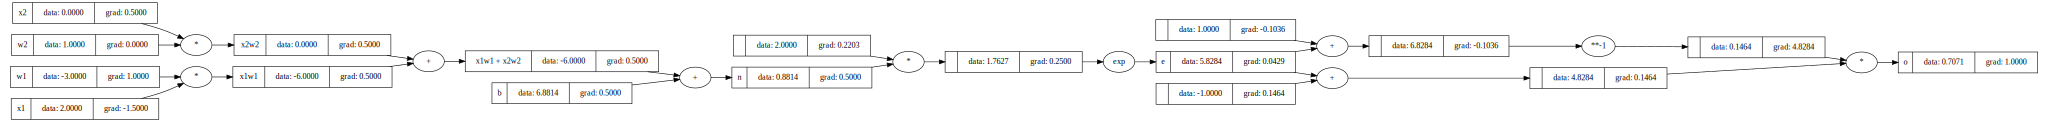

In [13]:
draw_dot(o)

In [14]:
# BUG: 
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = a * b; c.label = 'c'
d = a + b; d.label = 'd'
e = c * d; e.label = 'e'

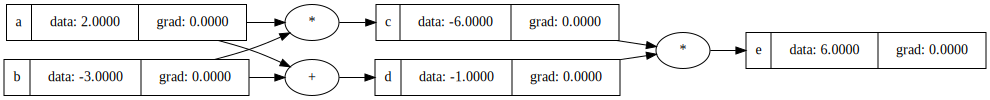

In [15]:
draw_dot(e)

In [16]:
e.backward()

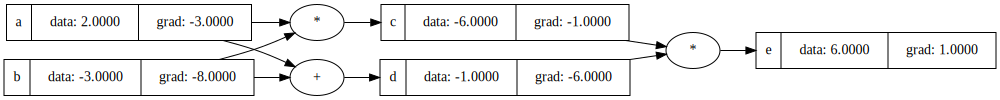

In [17]:
draw_dot(e)

In [18]:
a = Value(2.0, label='a')
f = a + a; f.label = 'f'
f.backward()

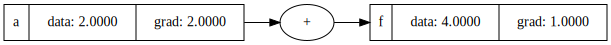

In [19]:
draw_dot(f)

In [20]:
2 + a


Value(data=4.0)

In [21]:
a - b

Value(data=5.0)

In [22]:
a - 1

Value(data=1.0)

In [23]:
1 - a

Value(data=-1.0)

In [24]:
a

Value(data=2.0)

In [25]:
a - 1

Value(data=1.0)

In [26]:
b

Value(data=-3.0)

In [27]:
a / b

Value(data=-0.6666666666666666)

In [28]:
a/2

Value(data=1.0)

In [29]:
3** -1

0.3333333333333333

In [30]:
# DOING THE SAME THING WITH PYTORCH
import torch

x1 = torch.tensor([2.0], requires_grad=True, dtype=torch.float64)
x2 = torch.tensor([0.0], requires_grad=True, dtype=torch.float64)

w1 = torch.tensor([-3.0], requires_grad=True, dtype=torch.float64)
w2 = torch.tensor([1.0], requires_grad=True, dtype=torch.float64)

b = torch.tensor([6.8813735870195432], requires_grad=True, dtype=torch.float64)

n = (x1 * w1) + (x2 *w2) + b
n.retain_grad()

o =  torch.tanh(n)
o.retain_grad()
o.backward()

print(f"x1: {x1.grad.item()}")
print(f"x2: {x2.grad.item()}")
print(f"w1: {w1.grad.item()}")
print(f"w1: {w2.grad.item()}")
print(f"b: {b.grad.item()}")
print(f"o: {o.data.item()}")
print(f"o.grad: {o.grad.item()}")

x1: -1.4999999999999998
x2: 0.49999999999999994
w1: 0.9999999999999999
w1: 0.0
b: 0.49999999999999994
o: 0.7071067811865476
o.grad: 1.0


In [31]:
n.grad

tensor([0.5000], dtype=torch.float64)

In [32]:
x1

tensor([2.], dtype=torch.float64, requires_grad=True)

In [33]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # return w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):   
        return [params for neuron in self.neurons for params in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1])for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [params for layer in self.layers for params in layer.parameters()]
    

In [34]:
x = [1.0, 2.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7658937112637749)

In [35]:
n.parameters()

[Value(data=0.9045800972623685),
 Value(data=-0.5223638882824277),
 Value(data=0.5302683492595301),
 Value(data=0.42140960350530543),
 Value(data=-0.33180819804595196),
 Value(data=0.5496417592982039),
 Value(data=-0.9381890635949808),
 Value(data=0.4310353400131981),
 Value(data=0.881764462353912),
 Value(data=-0.08544952467394729),
 Value(data=-0.3078812056309841),
 Value(data=0.5849720781789818),
 Value(data=-0.12932720867666614),
 Value(data=0.7930523442447015),
 Value(data=0.37030044945246043),
 Value(data=-0.5883694992504349),
 Value(data=-0.003910968538600512),
 Value(data=-0.9614858288384218),
 Value(data=0.594444959439731),
 Value(data=0.47220411201093726),
 Value(data=-0.8496325226709598),
 Value(data=-0.049430827045995995),
 Value(data=-0.7643397636783844),
 Value(data=0.08296209998587423),
 Value(data=-0.31966201236332226),
 Value(data=0.8004968503513716),
 Value(data=-0.10119649428128041),
 Value(data=-0.24617403073338995),
 Value(data=0.7875263935204657),
 Value(data=0.77

In [36]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [37]:
for i in range(30):

    # Forward pass
    y_pred = [n(x) for x in xs]
    loss = sum([(ygt - yout)**2 for ygt, yout in zip(ys, y_pred)])
    print(i, ' ===> ', loss)

    # Backward pass
    for p in n.parameters(): # Zero the grads
        p.grad = 0 
    loss.backward()

    # Update
    for params in n.parameters():
        params.data += -0.01 * params.grad

0  ===>  Value(data=6.657146092755992)
1  ===>  Value(data=6.484962055707507)
2  ===>  Value(data=6.276802066729138)
3  ===>  Value(data=6.024623703981202)
4  ===>  Value(data=5.720275415797156)
5  ===>  Value(data=5.357837868049299)
6  ===>  Value(data=4.937994949478146)
7  ===>  Value(data=4.473772549720936)
8  ===>  Value(data=3.9936310988260444)
9  ===>  Value(data=3.535327236662491)
10  ===>  Value(data=3.1301048589703124)
11  ===>  Value(data=2.7897506845720814)
12  ===>  Value(data=2.508011498340138)
13  ===>  Value(data=2.2711422344276753)
14  ===>  Value(data=2.066341616393503)
15  ===>  Value(data=1.8846725920994278)
16  ===>  Value(data=1.720756236168713)
17  ===>  Value(data=1.571599464206166)
18  ===>  Value(data=1.435560893449463)
19  ===>  Value(data=1.3116605198891667)
20  ===>  Value(data=1.1991777873457008)
21  ===>  Value(data=1.0974441893208269)
22  ===>  Value(data=1.0057558268305855)
23  ===>  Value(data=0.9233546447260976)
24  ===>  Value(data=0.8494442359055134)

In [38]:
y_pred

[Value(data=0.6469459939004651),
 Value(data=-0.7280636791739907),
 Value(data=-0.5513363132426193),
 Value(data=0.5754909176614157)]

In [39]:
n.parameters()

[Value(data=0.796470186235132),
 Value(data=-0.6562984762036562),
 Value(data=0.6396773326669545),
 Value(data=0.3654807406472933),
 Value(data=-0.4075672098654222),
 Value(data=0.4514416307166345),
 Value(data=-1.0771004026090767),
 Value(data=0.3071824337123278),
 Value(data=0.9064189713146908),
 Value(data=-0.033465535490821804),
 Value(data=-0.24777094557752335),
 Value(data=0.639532675849009),
 Value(data=-0.12630355024563916),
 Value(data=0.8229782663533123),
 Value(data=0.4115741975428066),
 Value(data=-0.5493238484860735),
 Value(data=0.20250728458332226),
 Value(data=-1.1789901809212613),
 Value(data=0.6904085894534219),
 Value(data=0.4281730655525919),
 Value(data=-0.6951598534675265),
 Value(data=-0.060718370806271744),
 Value(data=-0.7602915168995844),
 Value(data=0.06500746482344325),
 Value(data=-0.3242545490329762),
 Value(data=0.7723610640182684),
 Value(data=-0.1983002661597031),
 Value(data=-0.12810782172556942),
 Value(data=0.725847518982854),
 Value(data=0.833904974

In [40]:
len(n.parameters())

41